# Imports

In [11]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data

In [12]:
maison_df = pd.read_csv('datasets_prepd/dvf_maison.csv')
print(maison_df.head())

    id_mutation date_mutation  numero_disposition nature_mutation  \
0  2021-1289503    2021-01-05                   1           Vente   
1  2021-1289509    2021-01-06                   1           Vente   
2  2021-1289511    2021-01-04                   1           Vente   
3  2021-1289514    2021-01-05                   1           Vente   
4  2021-1289517    2021-01-04                   1           Vente   

   valeur_fonciere  adresse_numero adresse_suffixe      adresse_nom_voie  \
0         352000.0           228.0             NaN       RUE DE L EGLISE   
1         334800.0             7.0             NaN          AV ROSCOMMON   
2         225700.0            35.0             NaN  RUE DE LA REPUBLIQUE   
3         224000.0             7.0             NaN     CHE DE LA GARENNE   
4         267000.0            11.0             NaN     ALL DES AUBEPINES   

  adresse_code_voie  code_postal  ...  nature_culture_speciale  \
0              0220      77115.0  ...                      NaN

# Features

In [13]:
features = [
    "longitude",
    "latitude",
    "code_postal",
    "surface_reelle_bati",
    "nombre_pieces_principales",
    "surface_terrain",
    "number_of_lots",
    "season"
]

target = "valeur_fonciere_actualisee"

# Encode season to numeric values
season_mapping = {"winter": 0, "spring": 1, "summer": 2, "autumn": 3}
maison_df["season"] = maison_df["season"].map(season_mapping)

X = maison_df[features]
y = maison_df[target]

print("Number of features:", X.shape[1])
print(X.head())
print(y.head())

Number of features: 8
   longitude   latitude  code_postal  surface_reelle_bati  \
0   2.755044  48.527196      77115.0                120.0   
1   2.693202  48.486025      77590.0                100.0   
2   2.585738  48.715644      77170.0                 71.0   
3   2.984103  48.362632      77130.0                 69.0   
4   2.548109  48.605984      77176.0                 98.0   

   nombre_pieces_principales  surface_terrain  number_of_lots  season  
0                        3.0            331.0             NaN       0  
1                        4.0            337.0             NaN       0  
2                        3.0             55.0             NaN       0  
3                        3.0            763.0             NaN       0  
4                        5.0            205.0             NaN       0  
0    352000.0
1    334800.0
2    225700.0
3    224000.0
4    267000.0
Name: valeur_fonciere_actualisee, dtype: float64


# Make sets : trail and test and validate

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (26978, 8)
Validation: (5781, 8)
Test: (5782, 8)


# Ssave

In [15]:
os.makedirs("data_maison", exist_ok=True)

train_df = X_train.copy()
val_df = X_val.copy()
test_df = X_test.copy()

train_df[target] = y_train
val_df[target] = y_val
test_df[target] = y_test

train_df.to_csv("data_maison/maison_train.csv", index=False)
val_df.to_csv("data_maison/maison_val.csv", index=False)
test_df.to_csv("data_maison/maison_test.csv", index=False)

print("Datasets saved.")

Datasets saved.


Train model

In [16]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


# Feature importance

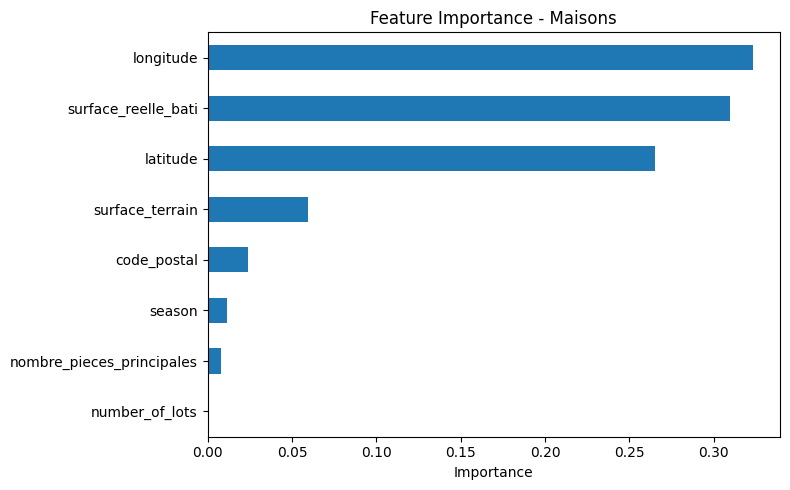


Feature importances:
  longitude: 0.3230
  surface_reelle_bati: 0.3093
  latitude: 0.2648
  surface_terrain: 0.0597
  code_postal: 0.0237
  season: 0.0115
  nombre_pieces_principales: 0.0080
  number_of_lots: 0.0000


In [17]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh')
plt.title("Feature Importance - Maisons")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nFeature importances:")
for name, imp in feat_imp.sort_values(ascending=False).items():
    print(f"  {name}: {imp:.4f}")

# Evaluation

In [18]:
# Evaluate on all 3 sets
for name, X_set, y_set in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    y_pred = model.predict(X_set)
    rmse = np.sqrt(mean_squared_error(y_set, y_pred))
    mae = mean_absolute_error(y_set, y_pred)
    r2 = r2_score(y_set, y_pred)
    erreur_pct = (abs(y_set - y_pred) / y_set * 100).mean()
    print(f"{name:10s} — RMSE: {rmse:>10.0f} | MAE: {mae:>10.0f} | R2: {r2:.4f} | Erreur moy: {erreur_pct:.2f}%")

# Overfitting gap
r2_train = r2_score(y_train, model.predict(X_train))
r2_val = r2_score(y_val, model.predict(X_val))
gap = r2_train - r2_val
print(f"\nGap surapprentissage (Train R2 - Val R2): {gap:.4f}")

Train      — RMSE:      58648 | MAE:      42212 | R2: 0.7504 | Erreur moy: 15.58%
Validation — RMSE:      73019 | MAE:      52993 | R2: 0.6203 | Erreur moy: 19.96%
Test       — RMSE:      71968 | MAE:      52122 | R2: 0.6330 | Erreur moy: 19.66%

Gap surapprentissage (Train R2 - Val R2): 0.1302


# Comparaison GradientBoosting

In [19]:
gb = HistGradientBoostingRegressor(
    max_iter=300, max_depth=6, learning_rate=0.1,
    min_samples_leaf=10, random_state=42
)
gb.fit(X_train, y_train)

for name, X_set, y_set in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    y_pred = gb.predict(X_set)
    r2 = r2_score(y_set, y_pred)
    erreur_pct = (abs(y_set - y_pred) / y_set * 100).mean()
    print(f"GB {name:10s} — R2: {r2:.4f} | Erreur moy: {erreur_pct:.2f}%")

gb_gap = r2_score(y_train, gb.predict(X_train)) - r2_score(y_val, gb.predict(X_val))
print(f"\nGB Gap surapprentissage: {gb_gap:.4f}")

GB Train      — R2: 0.7042 | Erreur moy: 17.55%
GB Validation — R2: 0.6286 | Erreur moy: 19.77%
GB Test       — R2: 0.6411 | Erreur moy: 19.59%

GB Gap surapprentissage: 0.0756


Save model

In [20]:
os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/maison_random_forest_model.pkl")

print("Model saved.")
print("Features sauvegardées:", list(model.feature_names_in_))

Model saved.
Features sauvegardées: ['longitude', 'latitude', 'code_postal', 'surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'number_of_lots', 'season']
